In [26]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [27]:
root="C:\\Users\\LENOVO\\Documents\\pytorch\\image_classifier\\afhq"
image_path = [] # Empty array where we will fill the paths of the images
labels = [] # Empty array where we will fill the labes of the images

for i in os.listdir(root): # Looping through the first directory which has the train and val images
  for label in os.listdir(f"{root}/{i}"):
    for image in os.listdir(f"{root}/{i}/{label}"):
        labels.append(label)
        image_path.append(f"{root}/{i}/{label}/{image}") # Append/Put this image path in the list to read it later

data_df = pd.DataFrame(zip(image_path, labels), columns = ['image_paths', 'labels']) # Create a dataframe contains the images paths and the labels
 

In [28]:
train=data_df.sample(frac=0.7,random_state=7) # Create training of 70% of the data
test=data_df.drop(train.index) # Create testing by removing the 70% of the train data which will result in 30%

val=test.sample(frac=0.5,random_state=7) # Create validation of 50% of the testing data
test=test.drop(val.index) # Create testing by removing the 50% of the validation data which will result in 50%
     

In [29]:
label_encoder = LabelEncoder() # Encode the string classes to numeric
label_encoder.fit(data_df['labels']) # Fit the label encoder on our own data

transform = transforms.Compose([
    transforms.Resize((128, 128)), # One size for all images
    transforms.ToTensor(), # Convert images to PyTorch tensors
    transforms.ConvertImageDtype(torch.float) # The values are in floating point numbers
    ]) 

In [30]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
          image = self.transform(image).to(device)

        return image, label
     

In [31]:
train_dataset = CustomImageDataset(dataframe=train, transform=transform)
val_dataset = CustomImageDataset(dataframe=val, transform=transform)
test_dataset = CustomImageDataset(dataframe=test, transform=transform)

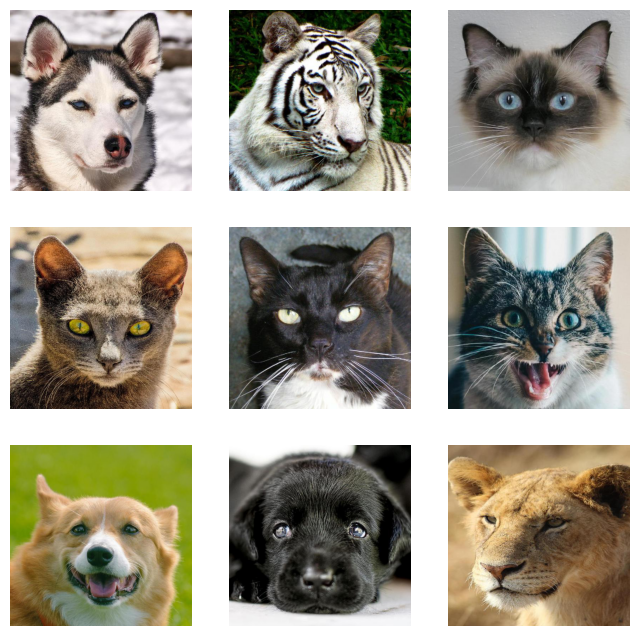

In [32]:

n_rows = 3
n_cols = 3
f, axarr = plt.subplots(n_rows, n_cols,figsize=(8,8))
for row in range(n_rows):
    for col in range(n_cols):
      image = Image.open(data_df.sample(n = 1)['image_paths'].iloc[0]).convert("RGB")
      axarr[row, col].imshow(image)
      axarr[row, col].axis('off')

plt.show()

In [33]:
#hyperparameter
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [34]:
#dataloader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)
images, labels = next(iter(train_loader))

print(type(images))
print(type(labels))
print(images.shape)
print(labels.shape)

<class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.Size([16, 3, 128, 128])
torch.Size([16])


# model 

In [35]:
class Net(nn.Module):
    def __init__(self):
        
        
        super().__init__()
        self.conv1=nn.Conv2d(3,32,kernel_size=3,padding=1)
        self.conv2=nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.conv3=nn.Conv2d(64,128,kernel_size=3,padding=1)

        self.pooling=nn.MaxPool2d(2,2)
        self.relu=nn.ReLU()
        self.flatten=nn.Flatten()
        self.linear=nn.Linear((128*16*16),128)


        self.output=nn.Linear(128,len(data_df['labels'].unique()))

    def forward(self,x):
       
       x=self.conv1(x) #(32,128,128)
       x=self.pooling(x)#(32,64,64)
       x=self.relu(x)#(32,64,64)
       x=self.conv2(x) #(64,64,64)
       x=self.pooling(x)#(64,32,32)
       x=self.relu(x)#(64,32,32)
       x=self.conv3(x) #(128,32,32)
       x=self.pooling(x)#(128,16,16)
       x=self.relu(x)#(128,16,16)
       x=self.flatten(x)
       x=self.linear(x)
       x=self.output(x)
       return x
       
    

model=Net()
model=model.to(device)
    

In [36]:
from torchsummary import summary
summary(model,input_size=(3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [37]:
criterion=nn.CrossEntropyLoss()
optimizer=Adam(model.parameters(),lr=LR)

In [38]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []


for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    labels=labels.long() 
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      labels=labels.long()  
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  total_acc_validation_plot.append(round(total_acc_val/(val_dataset.__len__())*100, 4))
  print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}
              Validation Loss: {round(total_loss_val/1000, 4)} Validation Accuracy: {round((total_acc_val)/val_dataset.__len__() * 100, 4)}''')
  print("="*25)
     

Epoch 1/10, Train Loss: 0.3408 Train Accuracy 79.0187
              Validation Loss: 0.037 Validation Accuracy: 90.8678
Epoch 2/10, Train Loss: 0.1339 Train Accuracy 93.1893
              Validation Loss: 0.0291 Validation Accuracy: 92.8926
Epoch 3/10, Train Loss: 0.0845 Train Accuracy 95.74
              Validation Loss: 0.0314 Validation Accuracy: 92.3967
Epoch 4/10, Train Loss: 0.0618 Train Accuracy 96.9268
              Validation Loss: 0.0218 Validation Accuracy: 95.0
Epoch 5/10, Train Loss: 0.0419 Train Accuracy 97.9807
              Validation Loss: 0.0189 Validation Accuracy: 95.7438
Epoch 6/10, Train Loss: 0.0344 Train Accuracy 98.1313
              Validation Loss: 0.0197 Validation Accuracy: 95.5785
Epoch 7/10, Train Loss: 0.0211 Train Accuracy 99.0789
              Validation Loss: 0.0186 Validation Accuracy: 95.8264
Epoch 8/10, Train Loss: 0.018 Train Accuracy 99.1232
              Validation Loss: 0.0219 Validation Accuracy: 95.4959
Epoch 9/10, Train Loss: 0.0132 Train Ac

In [44]:
# testing
with torch.no_grad():
    total_loss_test=0
    total_acc_test=0
    for inputs , labels in test_loader:
        labels=labels.long()
        prediction=model(inputs)
        test_loss=criterion(prediction,labels)
        total_loss_test+=test_loss.item()
        acc=(torch.argmax(prediction,axis=1)==labels).sum().item()
        total_acc_test+=acc
    print("test accuracy :",round(total_acc_test/test_dataset.__len__()*100,4))
    print('test loss: ',round(total_loss_test/1000,4))

test accuracy : 95.9901
test loss:  0.0216


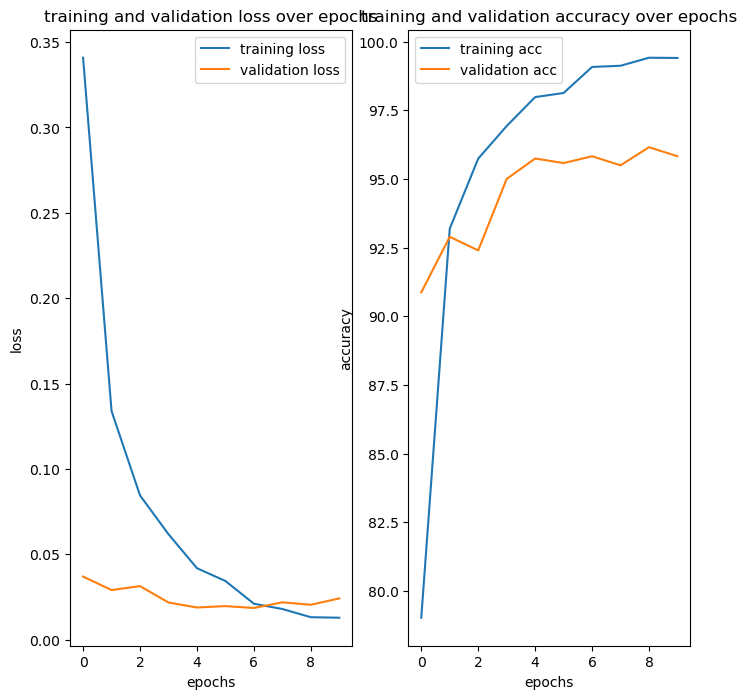

In [45]:
fig,axss=plt.subplots(1,2,figsize=(8,8))
axss[0].plot(total_loss_train_plot,label='training loss')
axss[0].plot(total_loss_validation_plot,label='validation loss')
axss[0].set_title('training and validation loss over epochs')
axss[0].set_xlabel('epochs')
axss[0].set_ylabel('loss')
axss[0].legend()


axss[1].plot(total_acc_train_plot,label='training acc')
axss[1].plot(total_acc_validation_plot,label='validation acc')
axss[1].set_title('training and validation accuracy over epochs')
axss[1].set_xlabel('epochs')
axss[1].set_ylabel('accuracy')
axss[1].legend()
plt.show()

In [46]:
#inference
def predict_image(img_path):
    image=Image.open(img_path).convert('RGB')
    image=transform(image).to(device).unsqueeze(dim=0)
    print(image.shape)
    output=model(image)
    output= torch.argmax(output,axis=1).item() #item return scalar value no dimention
    return label_encoder.inverse_transform([output])

In [47]:
img_path="C:\\Users\\LENOVO\\Documents\\pytorch\\image_classifier\\cate face _inference.jpg"
predict_image(img_path)

torch.Size([1, 3, 128, 128])


array(['cat'], dtype=object)